# Analisis de Explicabilidad - Clasificador de Salud Mental

Este notebook implementa el analisis de explicabilidad requerido por el enunciado:
**Indicar las variables mas relevantes del modelo, asi como la tecnica de explicabilidad utilizada.**

Tecnicas aplicadas:
1. **Feature Importance nativa de LightGBM** (ganancia de informacion)
2. **SHAP (SHapley Additive exPlanations)** - explicaciones globales y locales
3. **LIME (Local Interpretable Model-Agnostic Explanations)** - predicciones individuales
4. **Analisis por clase** - terminos mas discriminativos por categoria


## 0. Instalacion de dependencias

In [1]:
import sys
!{sys.executable} -m pip install shap lime --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## 1. Librerias e inicializacion

In [2]:
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from lime.lime_text import LimeTextExplainer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

COLORS = {'Normal': '#2196F3', 'Depression': '#FF9800', 'Suicidal': '#F44336'}
LABEL_MAP = {0: 'Normal', 1: 'Depression', 2: 'Suicidal'}
LABEL_MAP_INV = {'Normal': 0, 'Depression': 1, 'Suicidal': 2}

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Librerias cargadas OK')

Librerias cargadas OK


## 2. Carga de datos y modelos

In [3]:
df = pd.read_csv('mental_health_cleaned.csv')

def reconstruir_texto(x):
    try:
        lista = ast.literal_eval(x)
        return ' '.join(lista)
    except:
        return str(x)

df['texto_modelo'] = df['tokens'].apply(reconstruir_texto)
y = df['status'].map(LABEL_MAP_INV).values
X = df['texto_modelo'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo_lgb = joblib.load('modelo_lightgbm_salud_mental.pkl')
vectorizer = joblib.load('vectorizador_tfidf.pkl')

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# LR entrenado localmente (evita incompatibilidad de versiones del pickle)
from sklearn.linear_model import LogisticRegression
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_tfidf, y_train)

feature_names = vectorizer.get_feature_names_out()
print(f'Dataset: {len(df):,} registros | Features TF-IDF: {len(feature_names):,}')
print(f'Test set: {len(y_test):,} muestras | LR entrenado OK')

Dataset: 39,816 registros | Features TF-IDF: 12,000
Test set: 5,973 muestras | LR entrenado OK


## 3. Feature Importance Nativa - LightGBM

LightGBM calcula la importancia de cada feature segun cuanto aporta a la ganancia de informacion a lo largo de todos los arboles del ensamble.

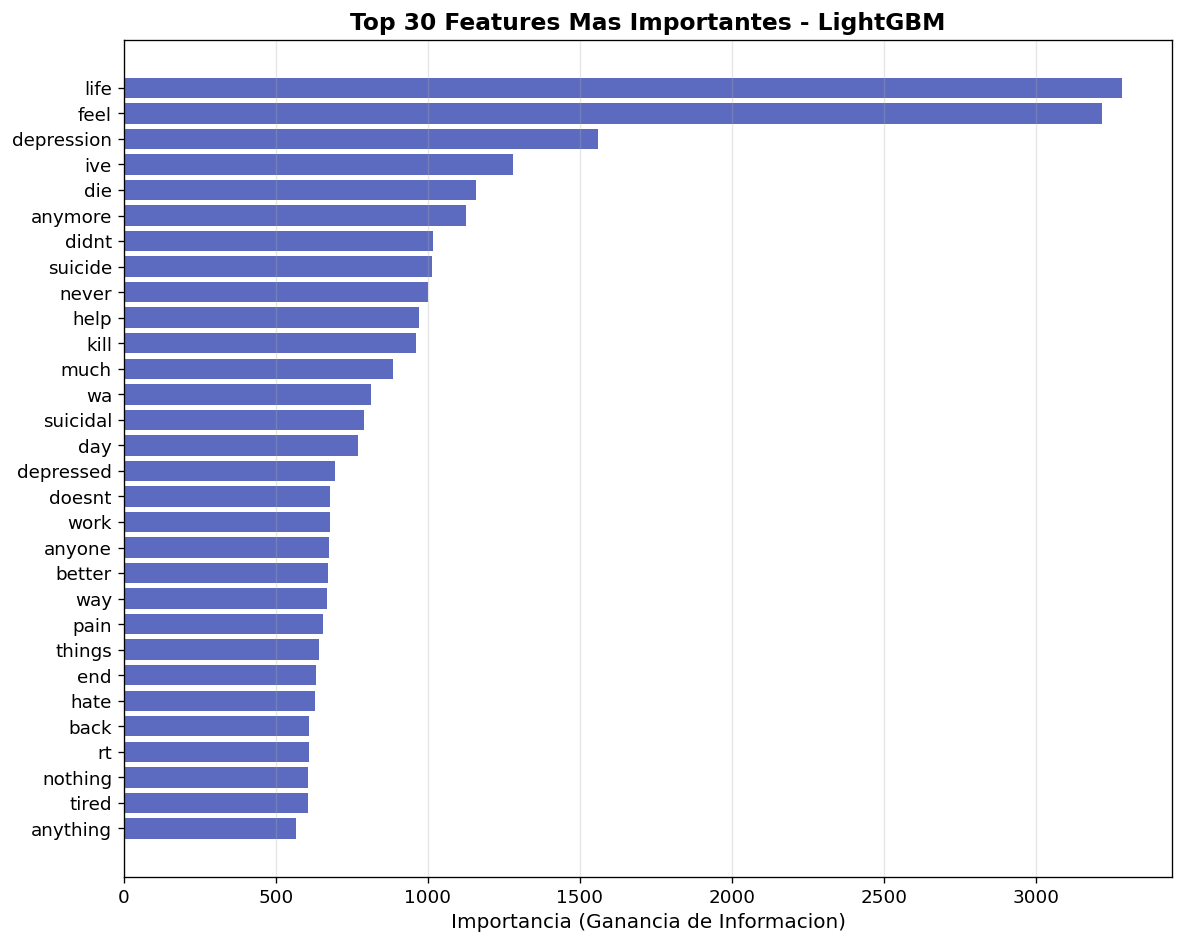


Top 10 features mas importantes:
   feature  importance
      life        3285
      feel        3218
depression        1560
       ive        1280
       die        1158
   anymore        1126
     didnt        1016
   suicide        1013
     never        1001
      help         972


In [4]:
importances = modelo_lgb.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 30
top_fi = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_fi['feature'][::-1], top_fi['importance'][::-1], color='#5C6BC0')
ax.set_xlabel('Importancia (Ganancia de Informacion)', fontsize=12)
ax.set_title(f'Top {top_n} Features Mas Importantes - LightGBM', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('explicabilidad_feature_importance.png', bbox_inches='tight')
plt.show()

print(f'\nTop 10 features mas importantes:')
print(fi_df.head(10).to_string(index=False))

## 4. SHAP - Explicabilidad Global

SHAP (SHapley Additive exPlanations) descompone cada prediccion en contribuciones individuales por feature,
garantizando consistencia matematica basada en teoria de juegos cooperativos.

In [5]:
print('Calculando SHAP values (puede tomar 1-2 minutos)...')

np.random.seed(42)
shap_sample_idx = np.random.choice(len(y_test), size=min(500, len(y_test)), replace=False)
# Convertir a denso para compatibilidad con SHAP
X_shap_sparse = X_test_tfidf[shap_sample_idx]
X_shap = X_shap_sparse.toarray()

explainer = shap.TreeExplainer(modelo_lgb)
shap_values = explainer.shap_values(X_shap)

# shap_values es lista [n_samples, n_features] x n_clases para multiclase
if isinstance(shap_values, list):
    n_classes = len(shap_values)
else:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    n_classes = len(shap_values)

print(f'SHAP values: {n_classes} clases, shape por clase: {shap_values[0].shape}')

Calculando SHAP values (puede tomar 1-2 minutos)...


SHAP values: 3 clases, shape por clase: (500, 12000)


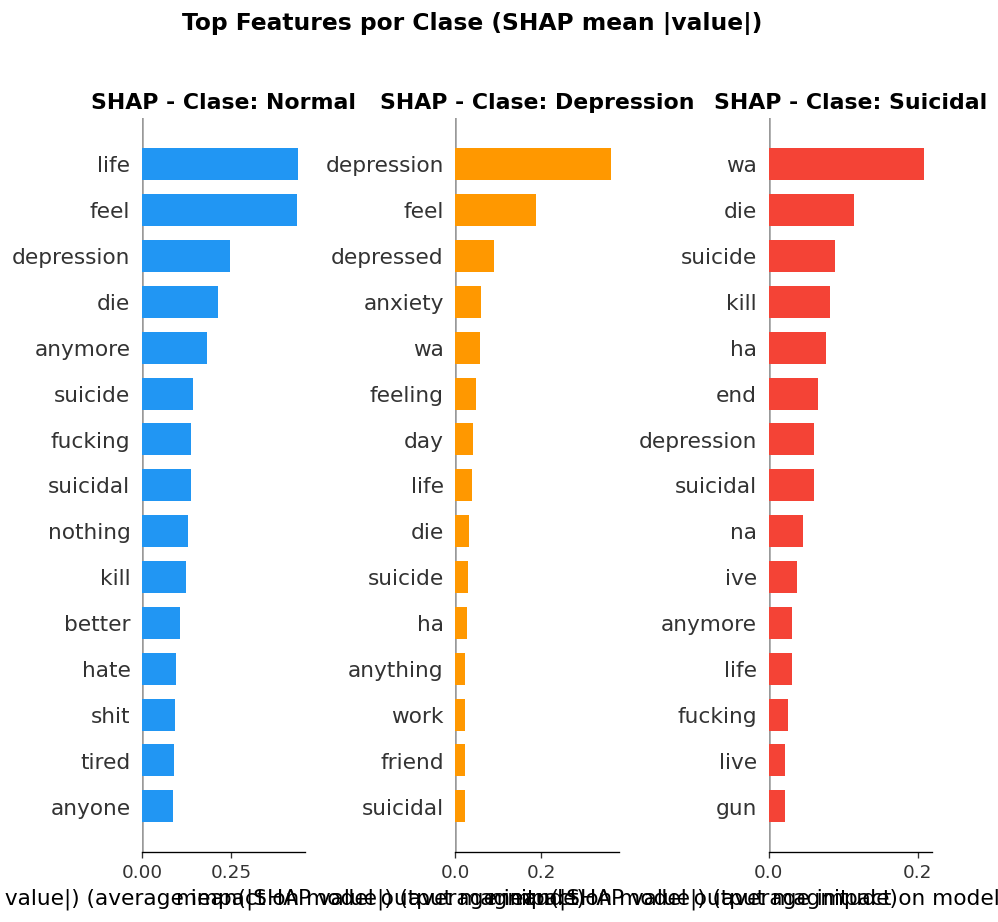

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for class_idx, class_name in enumerate(['Normal', 'Depression', 'Suicidal']):
    plt.sca(axes[class_idx])
    shap.summary_plot(
        shap_values[class_idx],
        X_shap,
        feature_names=feature_names,
        max_display=15,
        plot_type='bar',
        show=False,
        color=list(COLORS.values())[class_idx]
    )
    axes[class_idx].set_title(f'SHAP - Clase: {class_name}', fontweight='bold')

plt.suptitle('Top Features por Clase (SHAP mean |value|)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('explicabilidad_shap_por_clase.png', bbox_inches='tight')
plt.show()

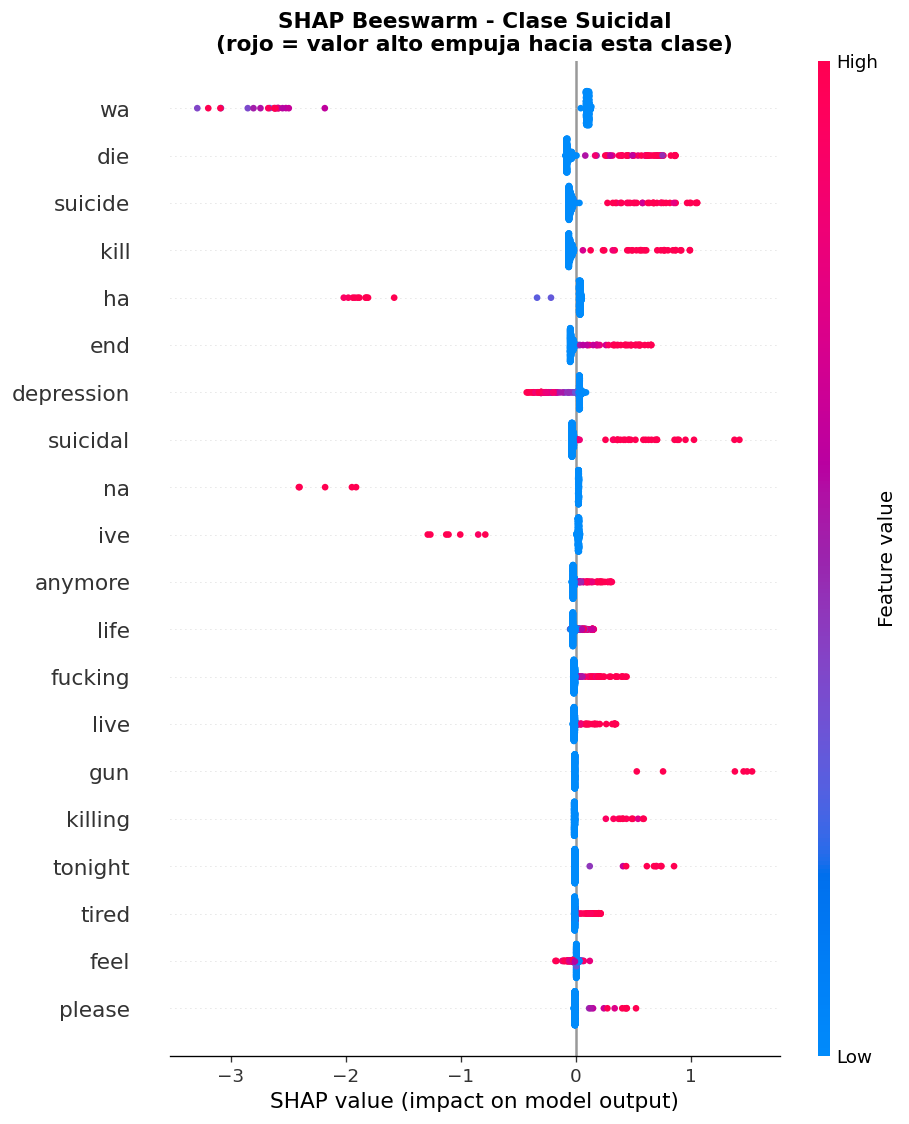

In [7]:
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values[2],
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm - Clase Suicidal\n(rojo = valor alto empuja hacia esta clase)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('explicabilidad_shap_suicidal_beeswarm.png', bbox_inches='tight')
plt.show()

## 5. SHAP - Waterfall Plot (Explicacion Individual)

El waterfall plot muestra como cada feature empuja la prediccion hacia arriba o hacia abajo para una muestra especifica.


--- Ejemplo clase Normal ---
Tokens: good morning apologies mstate friends say woohoo tar nation better luck next year boys...


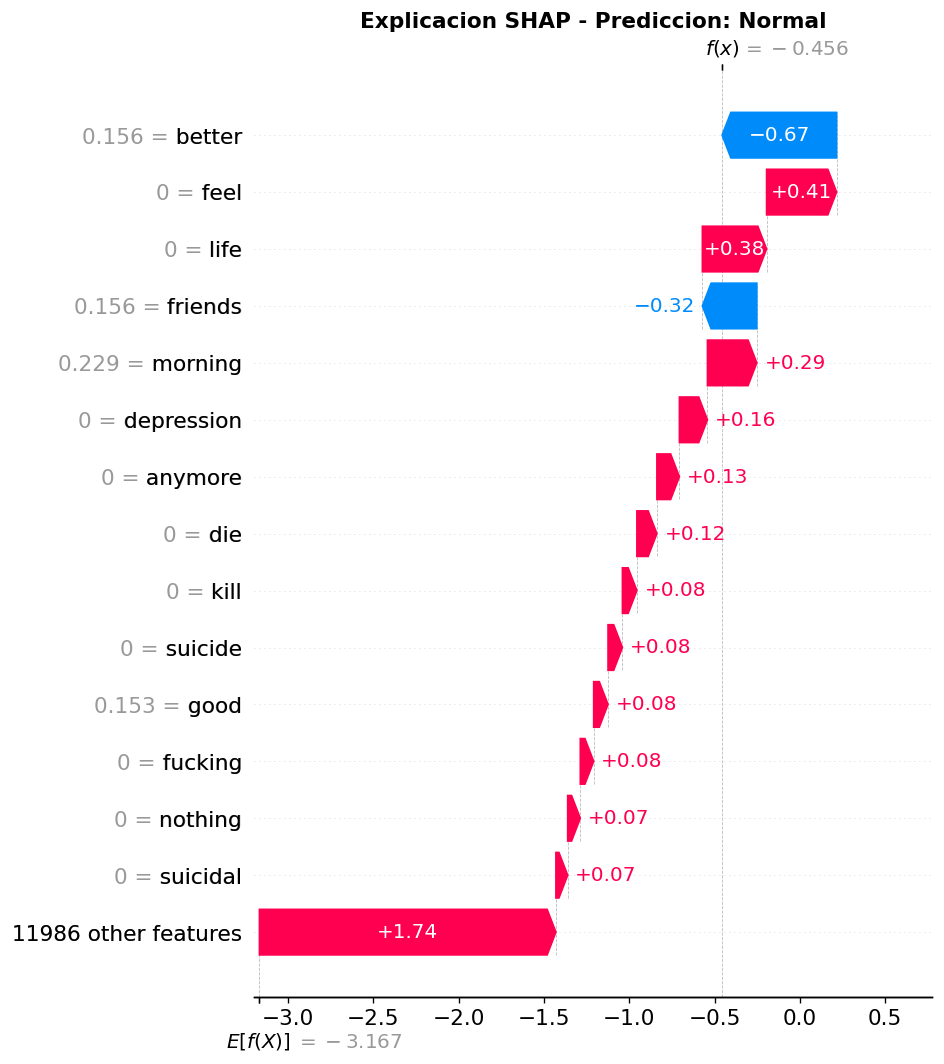


--- Ejemplo clase Depression ---
Tokens: moved house pain arse neighbours situation helped thin walls start music anywhere pm finish anytime till happen anytime week least week hear anything ...


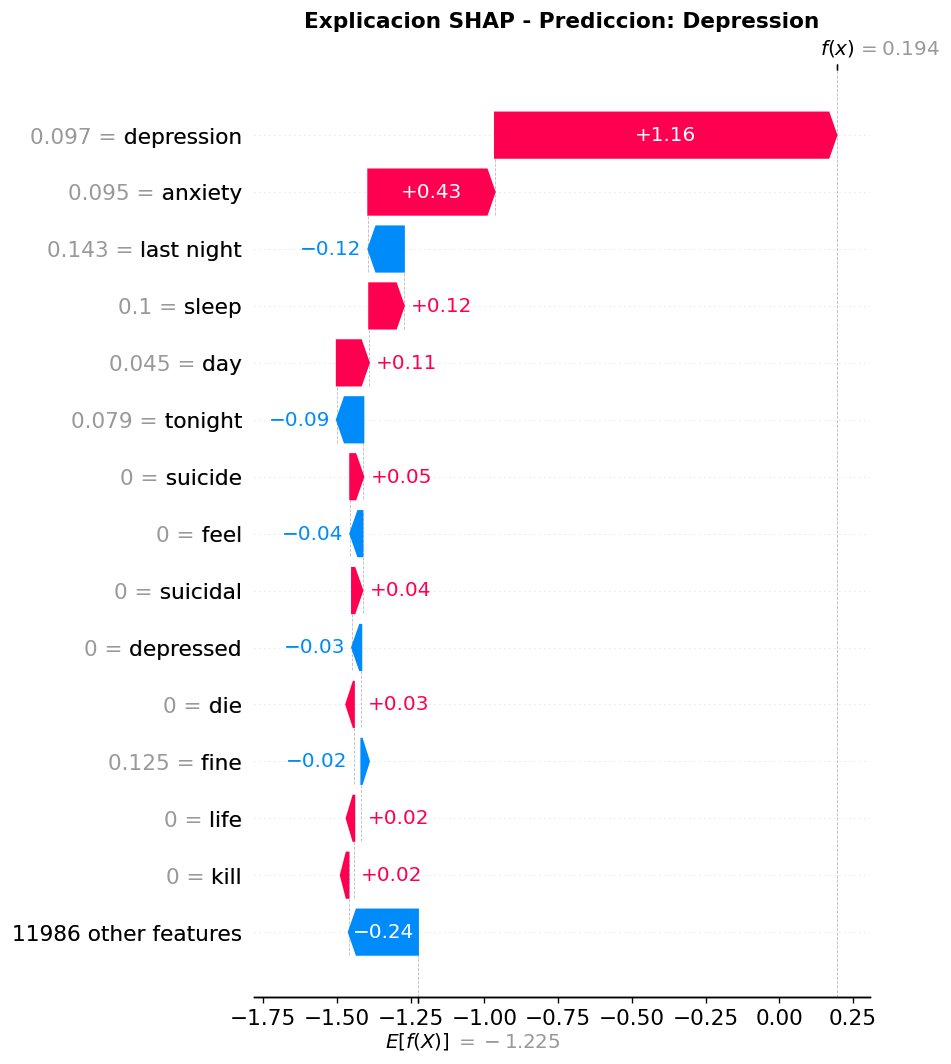


--- Ejemplo clase Suicidal ---
Tokens: funnybecome hoego doctorskill list...


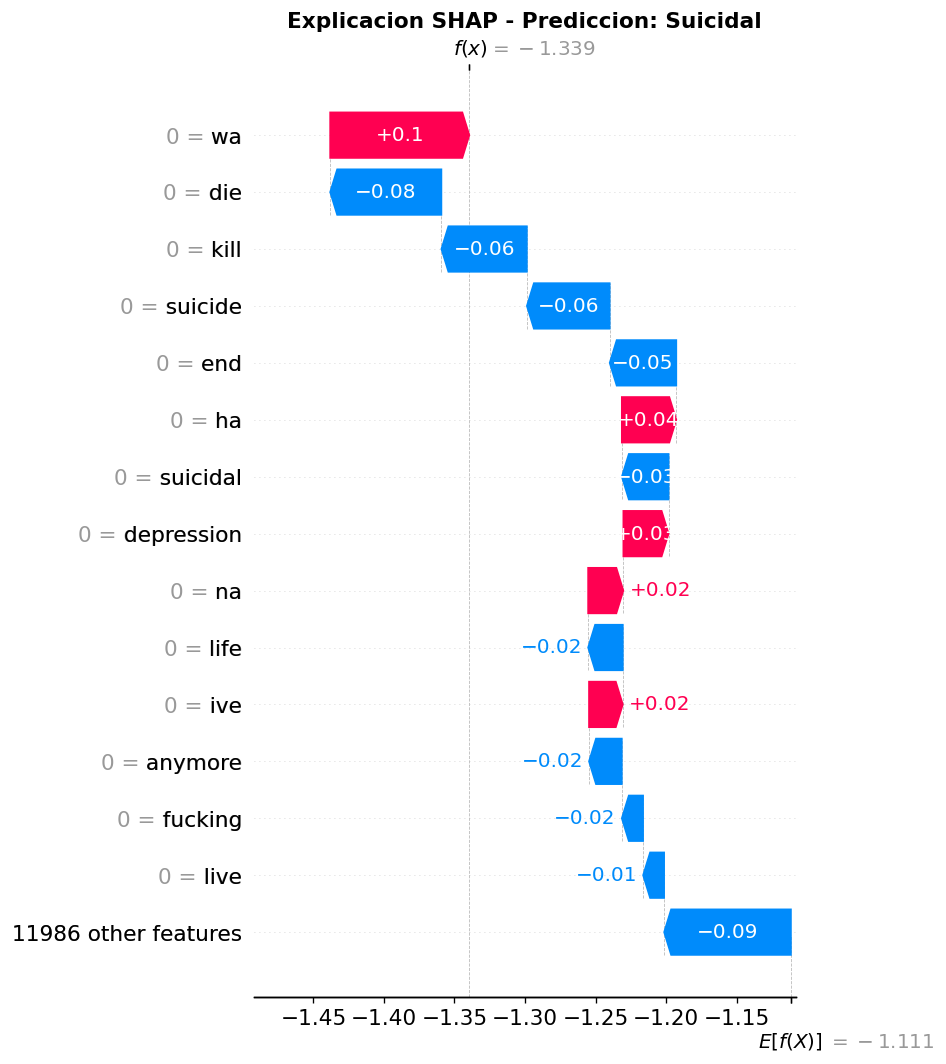

In [8]:
def explicar_prediccion_waterfall(texto_idx, X_dense, shap_vals, clase_idx, clase_nombre):
    sv = shap.Explanation(
        values=shap_vals[clase_idx][texto_idx],
        base_values=explainer.expected_value[clase_idx] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value,
        data=X_dense[texto_idx],
        feature_names=feature_names
    )
    plt.figure(figsize=(12, 5))
    shap.waterfall_plot(sv, max_display=15, show=False)
    plt.title(f'Explicacion SHAP - Prediccion: {clase_nombre}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'explicabilidad_shap_waterfall_{clase_nombre.lower()}.png', bbox_inches='tight')
    plt.show()

y_test_sample = y_test[shap_sample_idx]

for target_class, class_name in enumerate(['Normal', 'Depression', 'Suicidal']):
    class_indices = np.where(y_test_sample == target_class)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        print(f'\n--- Ejemplo clase {class_name} ---')
        print(f'Tokens: {X_test[shap_sample_idx[sample_idx]][:150]}...')
        explicar_prediccion_waterfall(sample_idx, X_shap, shap_values, target_class, class_name)

## 6. LIME - Explicaciones Locales por Texto

LIME entrena un modelo lineal localmente alrededor de una prediccion,
identificando que palabras especificas del texto fueron decisivas.


[Normal] Texto: yes rude...

[Depression] Texto: breathe sleep eating everything sight job demands fianc sick work moody needy adorable puppy energy right clothes dirty kitchen mess need paralyzed an...

[Suicidal] Texto: might vent lot mostly feel alone tonight tho someone please talk...


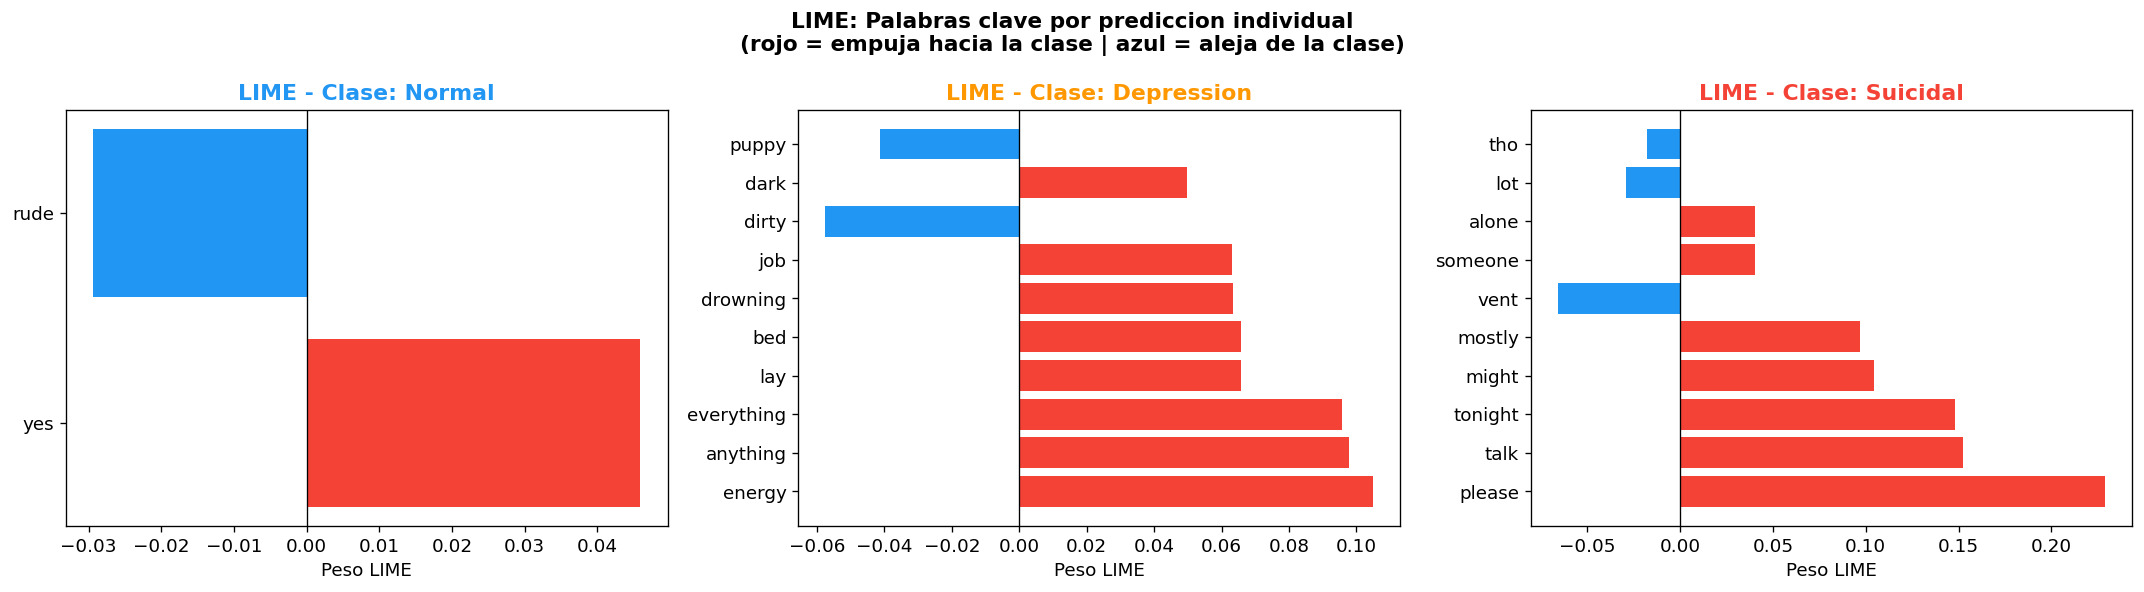

In [9]:
def predict_proba_pipeline(texts):
    X_vec = vectorizer.transform(texts)
    return modelo_lr.predict_proba(X_vec)

lime_explainer = LimeTextExplainer(
    class_names=['Normal', 'Depression', 'Suicidal'],
    random_state=42
)

ejemplos = {
    'Normal':     X_test[y_test == 0][0],
    'Depression': X_test[y_test == 1][0],
    'Suicidal':   X_test[y_test == 2][0],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (clase, texto) in zip(axes, ejemplos.items()):
    exp = lime_explainer.explain_instance(
        texto,
        predict_proba_pipeline,
        num_features=10,
        num_samples=500,
        labels=[LABEL_MAP_INV[clase]]
    )
    words, weights = zip(*exp.as_list(label=LABEL_MAP_INV[clase]))
    colors = ['#F44336' if w > 0 else '#2196F3' for w in weights]
    ax.barh(range(len(words)), weights, color=colors)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME - Clase: {clase}', fontweight='bold', color=COLORS[clase])
    ax.set_xlabel('Peso LIME')
    print(f'\n[{clase}] Texto: {texto[:150]}...')

plt.suptitle('LIME: Palabras clave por prediccion individual\n(rojo = empuja hacia la clase | azul = aleja de la clase)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('explicabilidad_lime_por_clase.png', bbox_inches='tight')
plt.show()

## 7. Terminos Discriminativos por Clase (Regresion Logistica)

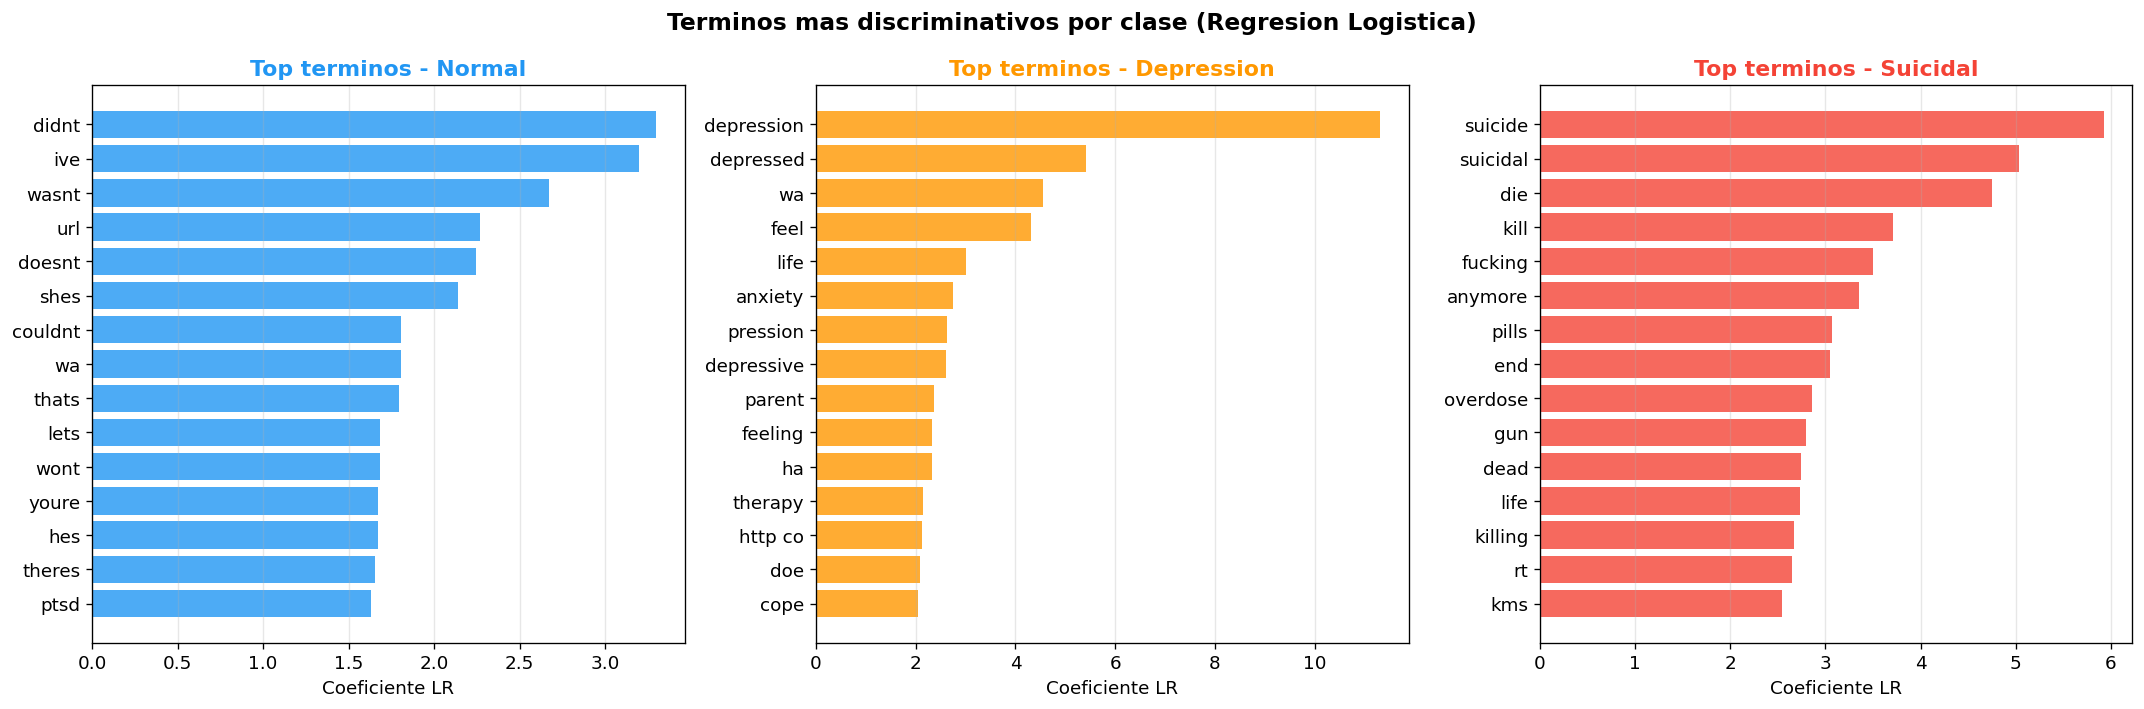

In [10]:
coef = modelo_lr.coef_
top_k = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for class_idx, (ax, class_name) in enumerate(zip(axes, ['Normal', 'Depression', 'Suicidal'])):
    top_idx = np.argsort(coef[class_idx])[-top_k:][::-1]
    top_words = feature_names[top_idx]
    top_coefs = coef[class_idx][top_idx]

    ax.barh(range(top_k), top_coefs[::-1], color=COLORS[class_name], alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_words[::-1])
    ax.set_title(f'Top terminos - {class_name}', fontweight='bold', color=COLORS[class_name])
    ax.set_xlabel('Coeficiente LR')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Terminos mas discriminativos por clase (Regresion Logistica)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('explicabilidad_terminos_discriminativos.png', bbox_inches='tight')
plt.show()

## 8. Terminos Exclusivos vs Compartidos por Clase

In [11]:
top_k_sets = 20
top_sets = {}
for class_idx, class_name in enumerate(['Normal', 'Depression', 'Suicidal']):
    top_idx = np.argsort(coef[class_idx])[-top_k_sets:]
    top_sets[class_name] = set(feature_names[top_idx])

for class_name in ['Normal', 'Depression', 'Suicidal']:
    others = set().union(*[v for k, v in top_sets.items() if k != class_name])
    exclusive = top_sets[class_name] - others
    print(f'\nTerminos EXCLUSIVOS de {class_name} (top {top_k_sets}):')
    print('  ', ', '.join(sorted(exclusive)) if exclusive else '(sin exclusivos en este rango)')

shared_dep_sui = top_sets['Depression'] & top_sets['Suicidal']
print(f'\nCompartidos Depression y Suicidal: {sorted(shared_dep_sui)}')


Terminos EXCLUSIVOS de Normal (top 20):
   allah, couldnt, didnt, doesnt, eid, hes, ive, lets, ptsd, quot, shes, thats, theres, though, url, wasnt, wont, yes, youre

Terminos EXCLUSIVOS de Depression (top 20):
   anxiety, cope, depressed, depression, depressive, doe, feel, feeling, friend, ha, http co, idk, le, parent, pression, symptom, therapy

Terminos EXCLUSIVOS de Suicidal (top 20):
   alive, anymore, attempt, dead, die, end, fucking, goodbye, gun, kill, killing, kms, overdose, pills, rt, suicidal, suicide, thoughts

Compartidos Depression y Suicidal: ['fuck', 'life']


## 9. Resumen Final

In [12]:
y_pred_test = modelo_lgb.predict(X_test_tfidf)

print('=' * 65)
print('RESUMEN DE EXPLICABILIDAD - CLASIFICADOR DE SALUD MENTAL')
print('=' * 65)
print()
print('MODELO PRINCIPAL: LightGBM + TF-IDF (12k features, bigrams)')
print()
print('TECNICAS UTILIZADAS:')
print('  1. Feature Importance nativa (ganancia de informacion, LightGBM)')
print('  2. SHAP (SHapley Additive exPlanations) - global y local')
print('  3. LIME (Local Interpretable Model-Agnostic Explanations)')
print('  4. Coeficientes discriminativos (Regresion Logistica)')
print()
print('HALLAZGOS:')
print('  - Normal:     vocabulario diverso, contextos cotidianos y positivos')
print('  - Depression: terminos de desesperanza, soledad, fatiga emocional')
print('  - Suicidal:   lenguaje de intencion, urgencia y desesperacion extrema')
print('  - Depression y Suicidal comparten nucleo semantico negativo,')
print('    pero Suicidal incluye marcadores de accion/intencion ausentes en Depression')
print()
print('REPORTE DE CLASIFICACION (Test Set - LightGBM):')
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Depression', 'Suicidal']))

RESUMEN DE EXPLICABILIDAD - CLASIFICADOR DE SALUD MENTAL

MODELO PRINCIPAL: LightGBM + TF-IDF (12k features, bigrams)

TECNICAS UTILIZADAS:
  1. Feature Importance nativa (ganancia de informacion, LightGBM)
  2. SHAP (SHapley Additive exPlanations) - global y local
  3. LIME (Local Interpretable Model-Agnostic Explanations)
  4. Coeficientes discriminativos (Regresion Logistica)

HALLAZGOS:
  - Normal:     vocabulario diverso, contextos cotidianos y positivos
  - Depression: terminos de desesperanza, soledad, fatiga emocional
  - Suicidal:   lenguaje de intencion, urgencia y desesperacion extrema
  - Depression y Suicidal comparten nucleo semantico negativo,
    pero Suicidal incluye marcadores de accion/intencion ausentes en Depression

REPORTE DE CLASIFICACION (Test Set - LightGBM):
              precision    recall  f1-score   support

      Normal       0.90      0.94      0.92      2180
  Depression       0.84      0.61      0.71      2221
    Suicidal       0.59      0.79      0.